In [ ]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import h5py
import numpy as np
import random
import bacco

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [ ]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

### Get Parameters

In [ ]:
wind_en      = []
wind_vel     = []
rho_rec      = []
sf_ts        = []
ef_kin       = []
ef_high      = []
f_re         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re.append(float(line.split()[1]))
        
wind_en   = (np.asarray(wind_en) - np.mean(wind_en)) / np.std(wind_en)
wind_vel  = (np.asarray(wind_vel) - np.mean(wind_vel)) / np.std(wind_vel)
rho_rec   = (np.asarray(rho_rec) - np.mean(rho_rec)) / np.std(rho_rec)
sf_ts     = (np.asarray(sf_ts) - np.mean(sf_ts)) / np.std(sf_ts)
ef_kin    = (np.asarray(ef_kin) - np.mean(ef_kin)) / np.std(ef_kin)
ef_high   = (np.asarray(ef_high) - np.mean(ef_high)) / np.std(ef_high)
f_re      = (np.asarray(f_re) - np.mean(f_re)) / np.std(f_re)

In [ ]:
fid_pars = np.array([wind_en[30], wind_vel[30], rho_rec[30], sf_ts[30], ef_kin[30], ef_high[30], f_re[30]])

dist = np.zeros(31)
for i in range(len(name_list)):
    pars_i = np.array([wind_en[i], wind_vel[i], rho_rec[i], sf_ts[i], ef_kin[i], ef_high[i], f_re[i]])
    dist[i] = np.sum((pars_i - fid_pars)**2)

In [655]:
def pars(i, mstar):

    arr = np.vstack( ( mstar, np.ones(len(mstar)) * wind_en[i],\
                        np.ones(len(mstar)) * wind_vel[i],\
                        np.ones(len(mstar)) * rho_rec[i],\
                        np.ones(len(mstar)) * sf_ts[i],\
                        np.ones(len(mstar)) * ef_kin[i],\
                        np.ones(len(mstar)) * ef_high[i],\
                        np.ones(len(mstar)) * f_re[i])).T

    return arr

#### Load the MTNG

In [ ]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)

### Load the Zooms

In [ ]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

In [ ]:
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
zoom = {}

loaded = []
for i in range(len(name_list)):
    if i<30:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_{:d}/hydro_output/".format(i)
    else:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), use_ids=True, numpart=4320)


In [ ]:
with open("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

In [ ]:
xmatch = {}

for i in range(len(name_list)):
    xmatch[name_list[i]] = utils.cross_match(zoom[name_list[i]], snap=264)

In [ ]:
m200b = np.log10(1e10 * mtng.fof['halo_m200b'])

mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

h_frac = np.zeros(len(final_sel))
for m in range(len(mbins)-1):
    h_frac[m] = np.where(( m200b[final_sel]>=mbins[m]) & ( m200b[final_sel]<mbins[m+1]))[0].shape[0] / \
             np.where(( m200b>=mbins[m]) & ( m200b<mbins[m+1]))[0].shape[0]

In [ ]:
zoom_split = {}
zoom_sel = {}
for i in range(len(name_list)):
    zoom_split[name_list[i]] = utils.split_halos(zoom[name_list[i]])

    zoom_sel[name_list[i]] = {}

    zoom_sel[name_list[i]]['sel'] = xmatch[name_list[i]]['ind'][:,np.newaxis,np.newaxis]
    zoom_sel[name_list[i]]['h_frac'] = h_frac[np.newaxis, :]

In [ ]:
zoom_smf = {}

Nbins = 10

for i in range(len(name_list)):
    zoom_smf[name_list[i]] = zoom_split[name_list[i]].halo_smf_draws(sel_mask=zoom_sel[name_list[i]], nbins=Nbins, draws=1)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(zoom_smf['LH_0']['mstar'][0], zoom_smf['LH_0']['smf'][0])

ax.set_xlabel(r"$M_\star\, [M_\odot/h]$", fontsize=16)
ax.set_ylabel(r"SMF $[h^3 Mpc^{-3} dex^{-1}]$", fontsize=16)

In [ ]:
train_sel = np.argsort(dist)[::-1][:25]
test_sel = list(set(range(31)) - set(train_sel))

In [657]:
#del smf_global, arr_global
pars_global = pars(train_sel[0], np.log10(zoom_smf[name_list[train_sel[0]]]['mstar'][0]) )
smf_global = np.log10(zoom_smf[name_list[train_sel[0]]]['smf'][0])

for i in range(len(train_sel)):
    mstar = np.log10(zoom_smf[name_list[train_sel[i]]]['mstar'][0])

    arr = pars(train_sel[i], mstar)

    pars_global = np.vstack((pars_global, arr))

    smf_global = np.hstack((smf_global, np.log10(zoom_smf[name_list[train_sel[i]]]['smf'][0])))

In [658]:
train_x = torch.asarray(pars_global, dtype=torch.float)
train_y = torch.asarray(smf_global, dtype=torch.float)

In [659]:
torch.set_num_threads(8)

### Build the GP Model

In [677]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=8))

    def initialize(self):
        # reset constant mean to something reasonable
        self.mean_module.constant.data.normal_(0, 0.1)

        # lengthscales (ARD) :
        # initialize in log-space so we get spread over ~[0.3, 3] in standardized units
        with torch.no_grad():
            ls = 0.5 + torch.rand_like(self.covar_module.base_kernel.lengthscale)
            self.covar_module.base_kernel.lengthscale.copy_(ls)

        # reset outputscale
        self.covar_module.outputscale = 1.0

        # reset likelihood noise to moderate value
        self.likelihood.noise = 0.05

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood(noise_constraint=gpytorch.constraints.GreaterThan(1e-2))
model = ExactGPModel(train_x, train_y, likelihood)

In [678]:
# # We will use the simplest form of GP model, exact inference
# class SpectralMixtureGPModel(gpytorch.models.ExactGP):
#     def __init__(self, train_x, train_y, likelihood):
#         super(SpectralMixtureGPModel, self).__init__(train_x, train_y, likelihood)
#         self.mean_module = gpytorch.means.ConstantMean()
#         self.covar_module = gpytorch.kernels.SpectralMixtureKernel(num_mixtures=4)
#         #self.covar_module.initialize_from_data(train_x, train_y)

#     def forward(self, x):
#         mean_x = self.mean_module(x)
#         covar_x = self.covar_module(x)
#         return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# # initialize likelihood and model
# likelihood = gpytorch.likelihoods.GaussianLikelihood()
# model = SpectralMixtureGPModel(train_x, train_y, likelihood)

#### Train it

In [679]:
# this is for running the notebook in our testing framework
import os
import copy
smoke_test = ('CI' in os.environ)
#training_iter = 2 if smoke_test else 200

n_restarts = 30
steps_per_restart = 30

best_state = None
best_loss = float('inf')

for r in range(n_restarts):
    print(f"\n=== Restart {r+1}/{n_restarts} ===")
    model.initialize()

    # Find optimal model hyperparameters
    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Includes GaussianLikelihood parameters

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(steps_per_restart):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -torch.sum(mll(output, train_y))
        loss.backward()
        optimizer.step()

    # compute final loss for this restart
    with torch.no_grad():
        final_output = model(train_x)
        final_loss = float(-mll(final_output, train_y))

    print(f"Final loss restart {r+1}: {final_loss:.4f}")

    # store best
    if final_loss < best_loss:
        best_loss = final_loss
        best_state = {
            'model': copy.deepcopy(model.state_dict()),
            'likelihood': copy.deepcopy(likelihood.state_dict()),
        }


=== Restart 1/30 ===
Final loss restart 1: 0.8768

=== Restart 2/30 ===
Final loss restart 2: 0.6682

=== Restart 3/30 ===
Final loss restart 3: 0.4495

=== Restart 4/30 ===
Final loss restart 4: 0.2676

=== Restart 5/30 ===
Final loss restart 5: 0.2005

=== Restart 6/30 ===
Final loss restart 6: 0.1394

=== Restart 7/30 ===
Final loss restart 7: 0.0197

=== Restart 8/30 ===
Final loss restart 8: -0.0312

=== Restart 9/30 ===
Final loss restart 9: -0.0734

=== Restart 10/30 ===
Final loss restart 10: -0.1049

=== Restart 11/30 ===
Final loss restart 11: -0.1339

=== Restart 12/30 ===
Final loss restart 12: -0.1449

=== Restart 13/30 ===
Final loss restart 13: -0.1766

=== Restart 14/30 ===
Final loss restart 14: -0.1877

=== Restart 15/30 ===
Final loss restart 15: -0.2151

=== Restart 16/30 ===
Final loss restart 16: -0.2270

=== Restart 17/30 ===
Final loss restart 17: -0.2437

=== Restart 18/30 ===
Final loss restart 18: -0.2493

=== Restart 19/30 ===
Final loss restart 19: -0.2619

In [680]:
# ---- restore best ----
model.load_state_dict(best_state['model'])
likelihood.load_state_dict(best_state['likelihood'])

<All keys matched successfully>

In [681]:
print(model.covar_module.base_kernel.lengthscale)
print(model.covar_module.outputscale)
print(torch.sqrt(model.likelihood.noise_covar.noise))

tensor([[2.2589, 7.8305, 5.0967, 8.8135, 8.8780, 8.8539, 8.8704, 8.8617]],
       grad_fn=<SoftplusBackward0>)
tensor(1.1792, grad_fn=<SoftplusBackward0>)
tensor([0.1997], grad_fn=<SqrtBackward0>)


In [ ]:
print(model.covar_module.base_kernel.lengthscale)
print(model.covar_module.outputscale)
print(torch.sqrt(model.likelihood.noise_covar.noise))

In [ ]:
print(model.covar_module.base_kernel.lengthscale)
print(model.covar_module.outputscale)
print(torch.sqrt(model.likelihood.noise_covar.noise))

In [682]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# # Test points are regularly spaced along [0,1]
# # Make predictions by feeding model through likelihood
# with torch.no_grad(), gpytorch.settings.fast_pred_var():
#     #smf_test = model(mstar_test)
#     observed_pred1 = likelihood(model(torch.asarray(test_x1, dtype=torch.float)))

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

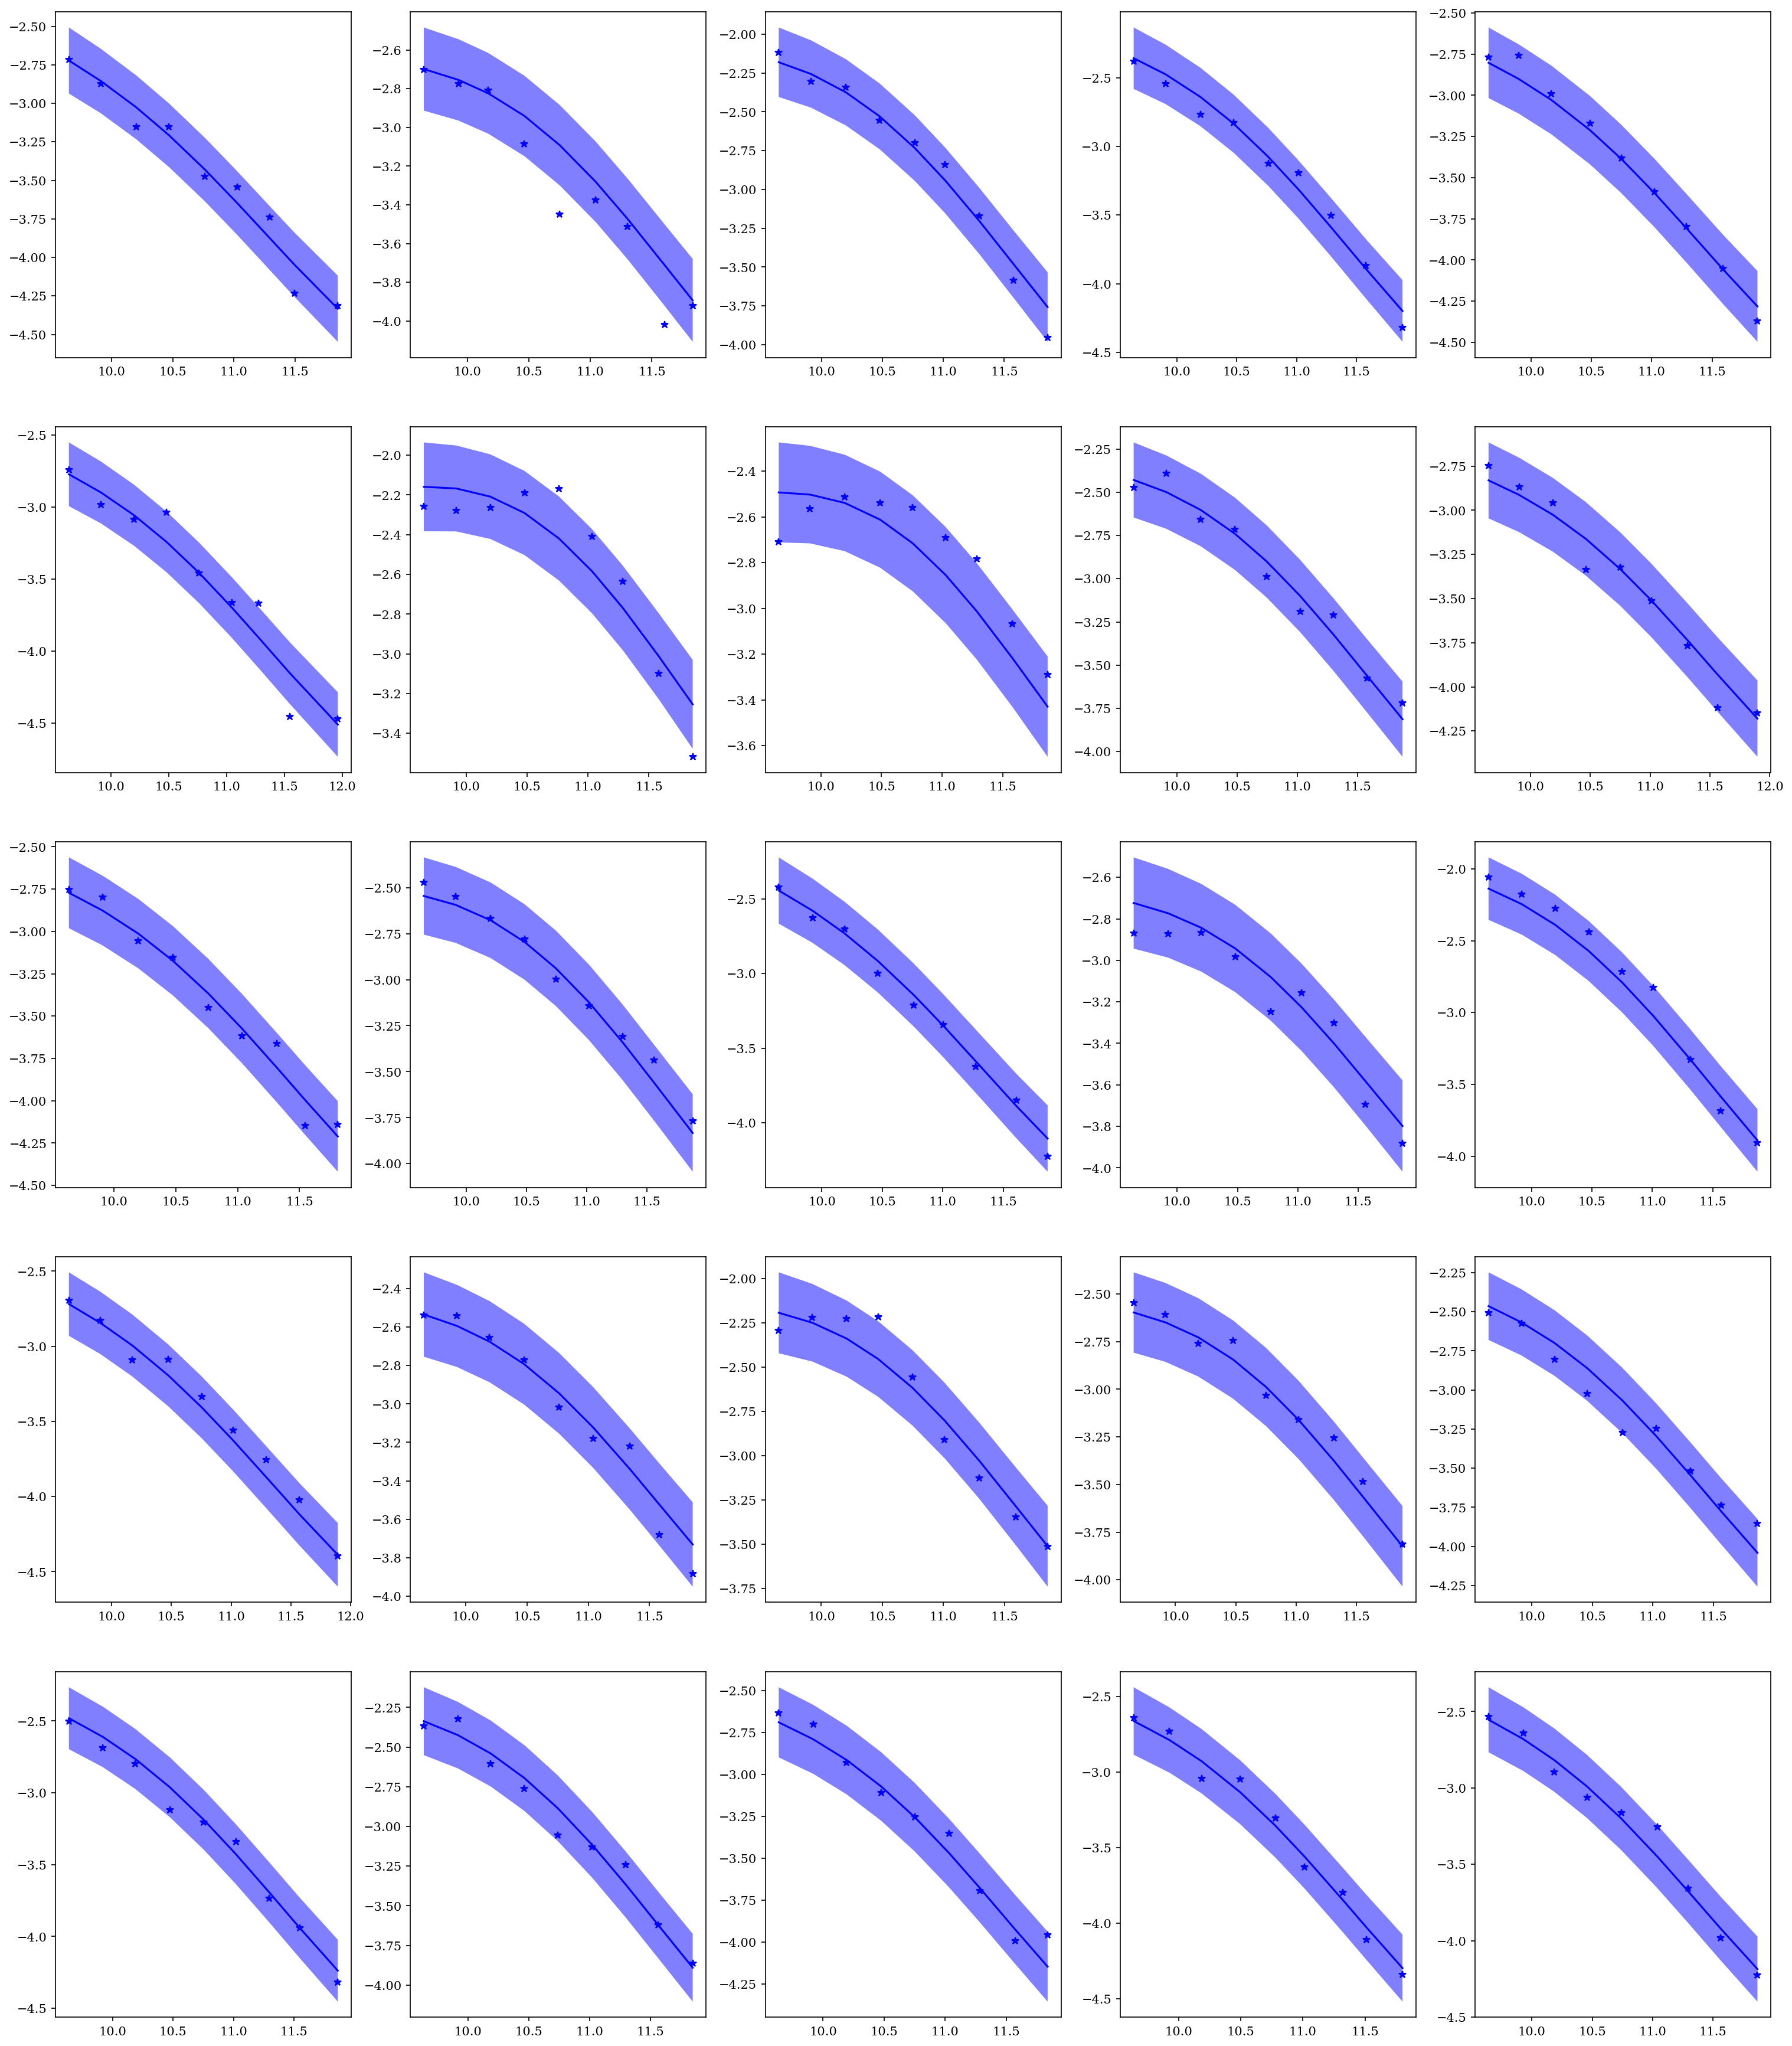

In [683]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(5, 5, figsize=(25, 30), dpi=150)

    for i in range(5):
        for j in range(5):
    
            test_x = torch.asarray(pars(train_sel[5*i+j], np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['mstar'][0])), dtype=torch.float)
            observed_pred = likelihood(model(torch.asarray(test_x, dtype=torch.float)))
        
            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()
            # Plot training data as black stars
            ax[i,j].plot(np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['mstar'][0]), np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['smf'][0]), 'b*')

            # Plot predictive means as blue line
        #    for i in range(10):
        #        ax.plot(mstar_test, smf_test.sample().numpy(), 'b', ls='--', lw=0.5)
            ax[i,j].plot(test_x[:,0], observed_pred.mean.numpy(), 'b')

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(test_x[:,0].numpy(), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='b', alpha=0.5, edgecolor=None)

# ax.set_xlabel('$M_*$')
# ax.set_ylabel('SMF')


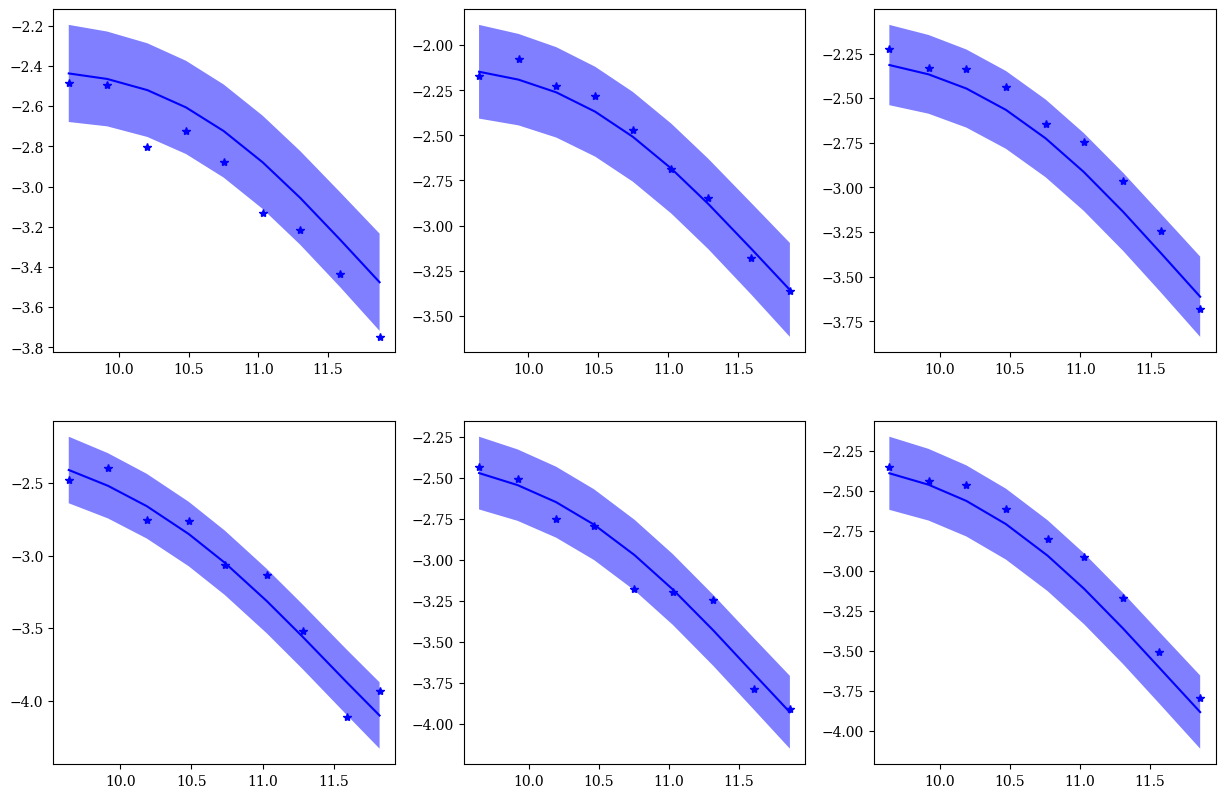

In [684]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(2, 3, figsize=(15, 10), dpi=100)

    for i in range(2):
        for j in range(3):
            # ax[i,j].set_ylim(-5, -1)
            test_x = torch.asarray(pars(test_sel[3*i+j], np.log10(zoom_smf[name_list[test_sel[3*i+j]]]['mstar'][0])), dtype=torch.float)
            observed_pred = likelihood(model(torch.asarray(test_x, dtype=torch.float)))
        
            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()
            # Plot test data as black stars
            ax[i,j].plot(np.log10(zoom_smf[name_list[test_sel[3*i+j]]]['mstar'][0]), np.log10(zoom_smf[name_list[test_sel[3*i+j]]]['smf'][0]), 'b*')

            # Plot predictive means as blue line
        #    for i in range(10):
        #        ax.plot(mstar_test, smf_test.sample().numpy(), 'b', ls='--', lw=0.5)
            ax[i,j].plot(test_x[:,0], observed_pred.mean.numpy(), 'b')

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(test_x[:,0].numpy(), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='b', alpha=0.5, edgecolor=None)

# ax.set_xlabel('$M_*$')
# ax.set_ylabel('SMF')


In [ ]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=150, sharey=True)
    
    plt.subplots_adjust(wspace=0, hspace=0)

    for i in range(40):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x1 = torch.asarray(pars(train_sel[i], np.log10(smf[train_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred1 = likelihood(model(test_x1))
    
        ax[0].plot(np.log10(smf[train_sel[i]]['mstar'][:-5]),  np.log10(smf[train_sel[i]]['smf'][:-5]) - observed_pred1.mean.numpy(), color='b', lw=0.7)
        ax[0].fill_between(np.log10(smf[train_sel[i]]['mstar'][:-5]), np.log10(smf[train_sel[i]]['smf'][:-5]) - (observed_pred1.mean.numpy()-observed_pred1.stddev.numpy()) , np.log10(smf[train_sel[i]]['smf'][:-5]) - (observed_pred1.mean.numpy()+observed_pred1.stddev.numpy()), alpha=0.05, color='b', edgecolor=None)

    for i in range(60):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x2 = torch.asarray(pars(test_sel[i], np.log10(smf[test_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred2 = likelihood(model(test_x2))
        
        ax[1].plot(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - observed_pred2.mean.numpy(), color='r', lw=0.7)
        ax[1].fill_between(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - (observed_pred2.mean.numpy()-observed_pred2.stddev.numpy()) , np.log10(smf[test_sel[i]]['smf'][:-5]) - (observed_pred2.mean.numpy()+observed_pred1.stddev.numpy()), alpha=0.05, color='r', edgecolor=None)
#        ax[1].fill_between(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - lower2.numpy(), np.log10(smf[test_sel[i]]['smf'][:-5]) - upper2.numpy(), alpha=0.01, color='r', edgecolor=None)

    # Plot training data as black stars
    ax[0].axhline(0, color='k', ls='--')
    ax[1].axhline(0, color='k', ls='--')

ax[0].set_ylabel('$\Delta \log_{10}(\\mathrm{SMF})$')
ax[0].set_xlabel('Stellar Mass $M_*[M_\odot]$')
ax[1].set_xlabel('Stellar Mass $M_*[M_\odot]$')

ax[0].set_title('Training Data [1-40]')
ax[1].set_title('Validation Data [41-100]')

In [ ]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=150, sharey=True)
    
    plt.subplots_adjust(wspace=0, hspace=0)

    # Get upper and lower confidence bounds
    lower1, upper1 = observed_pred1.confidence_region()
    lower2, upper2 = observed_pred2.confidence_region()
    # Plot training data as black stars
    ax[0].axhline(1, color='k', ls='--')
    ax[1].axhline(1, color='k', ls='--')

    for i in range(40):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x1 = torch.asarray(pars(train_sel[i], np.log10(smf[train_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred1 = likelihood(model(test_x1))
            lower1, upper1 = observed_pred1.confidence_region()
    
        ax[0].plot(np.log10(smf[train_sel[i]]['mstar'][:-5]),  smf[train_sel[i]]['smf'][:-5] / 10**observed_pred1.mean.numpy(), color='b', ls='', marker='o', ms=1)

    for i in range(60):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x2 = torch.asarray(pars(test_sel[i], np.log10(smf[test_sel[i]]['mstar'][:-4])), dtype=torch.float)
            observed_pred2 = likelihood(model(test_x2))
            lower2, upper2 = observed_pred2.confidence_region()
        
        ax[1].plot(np.log10(smf[test_sel[i]]['mstar'][:-4]), smf[test_sel[i]]['smf'][:-4] / 10**observed_pred2.mean.numpy(), color='r', ls='', marker='o', ms=1)

ax[0].set_ylabel('SMF Ratio')
ax[0].set_xlabel('Stellar Mass $M_*[M_\odot]$')
ax[1].set_xlabel('Stellar Mass $M_*[M_\odot]$')

ax[0].set_title('Training Data [1-40]')
ax[1].set_title('Validation Data [41-100]')